In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os.path as path
import utils
import matplotlib.pyplot as plt
from collections import Counter

In [ ]:
lau_df = utils.load_complex_geojson(path.join(utils.out_data_dir, "drought_days_lau.geojson"))
nuts3_df = utils.load_complex_geojson(path.join(utils.out_data_dir, "nuts3_stats.geojson"))
country_df = pd.read_json(path.join(utils.out_data_dir, "country_stats.geojson"))

# Most drought-stricken countries
This outputs all analyzed countries in order, based on how many drought days they experience on average per year.

In [6]:
country_df.sort_values(by="median_drought_days", ascending=False)["NAME_ENGL"].values

array(['Albania', 'Serbia', 'Poland', 'Liechtenstein', 'North Macedonia',
       'Bulgaria', 'Greece', 'Lithuania', 'Switzerland', 'Romania',
       'France', 'Croatia', 'Czechia', 'Slovenia', 'Slovakia', 'Spain',
       'Italy', 'Cyprus', 'Luxembourg', 'United Kingdom', 'Germany',
       'Hungary', 'Belgium', 'Netherlands', 'Ireland', 'Austria', 'Malta',
       'Portugal', 'Denmark', 'Sweden', 'Finland', 'Iceland', 'Estonia',
       'Norway', 'Latvia'], dtype=object)

In [23]:
len(country_df)

35

# Europe-wide statistics
This section splits the nuts3-dataset along a threshold for median and maximum drought days. From this it computes a portion of surface area

In [25]:
drought_days_median_50_mask = nuts3_df["median_drought_days"] > 50
dry_nuts3_df = nuts3_df[drought_days_median_50_mask]
wet_nuts3_df = nuts3_df[~drought_days_median_50_mask]
dryland_km2, wetland_km2 = dry_nuts3_df["area_km2"].sum(), wet_nuts3_df["area_km2"].sum()
dryland_km2 / (dryland_km2+wetland_km2)

np.float64(0.6541255404617256)

--> almost two third of the EEA+UK area experiences on average more than 50 days of drought warnings per year.

In [26]:
drought_days_median_100_mask = nuts3_df["median_drought_days"] > 100
dry_nuts3_df = nuts3_df[drought_days_median_100_mask]
wet_nuts3_df = nuts3_df[~drought_days_median_100_mask]
dryland_km2, wetland_km2 = dry_nuts3_df["area_km2"].sum(), wet_nuts3_df["area_km2"].sum()
dryland_km2 / (dryland_km2+wetland_km2)

np.float64(0.11943094078060766)

--> Over 10% of the EEA+UK area experiences on average more than 100 days of drought warnings per year.

In [19]:
drought_days_max_183_mask = nuts3_df["max_drought_days"] >= 183
dry_nuts3_df = nuts3_df[drought_days_max_183_mask]
wet_nuts3_df = nuts3_df[~drought_days_max_183_mask]
dryland_km2, wetland_km2 = dry_nuts3_df["area_km2"].sum(), wet_nuts3_df["area_km2"].sum()
dryland_km2 / (dryland_km2+wetland_km2)

np.float64(0.6648711964996835)

--> Two thirds of all regions in EEA+UK have experienced a severe drought year since 2012, in which a drought warning was issued for over 183 Days (half a year).

In [31]:
lau_df.sort_values(by="max_drought_days", ascending=False).iloc[:600]["CNTR_CODE"].value_counts()

CNTR_CODE
FR    217
CZ    138
ES     98
EL     53
IT     43
RO     25
SK     12
CH      7
HU      4
MT      1
AL      1
BE      1
Name: count, dtype: int64

In [35]:
nuts3_df.sort_values(by="max_drought_days", ascending=False).iloc[:600]

,nuts_id,cntr_code,name_latn,nuts_name,area_km2,population,cropland_km2,cropland_km2_by_type,cropland_area_percent,warning_days,...,max_warning_days_year,alert_days,median_alert_days,max_alert_days,max_alert_days_year,drought_days,median_drought_days,max_drought_days,max_drought_days_year,geometry
549,DEG0D,DE,Sömmerda,Sömmerda,805.78,67693.0,589.23,"{'Wheat': 216.4, 'Barley': 129.17, 'Maize': 62...",73.13,"[94.34, 0.36, 1.05, 113.55, 79.71, 47.87, 182....",...,2019.0,"[10.63, 0.0, 0.0, 0.69, 0.5, 17.19, 13.41, 4.4...",2.95,17.19,2017.0,"[104.97, 0.36, 1.05, 114.24, 80.21, 65.06, 196...",92.59,359.88,2019.0,"POLYGON ((11.10779 51.31099, 11.10777 51.30925..."
506,DED51,DE,"Leipzig, Kreisfreie Stadt","Leipzig, Kreisfreie Stadt",299.99,611850.0,74.18,"{'Wheat': 26.5, 'Barley': 15.39, 'Maize': 8.64...",24.73,"[23.35, 0.63, 19.41, 42.35, 21.13, 7.57, 186.5...",...,2019.0,"[2.78, 0.0, 0.0, 1.43, 0.0, 9.38, 2.4, 1.55, 1...",1.23,9.38,2017.0,"[26.13, 0.63, 19.41, 43.78, 21.13, 16.95, 188....",34.96,359.85,2019.0,"POLYGON ((12.33315 51.41909, 12.35463 51.41771..."
511,DEE03,DE,"Magdeburg, Kreisfreie Stadt","Magdeburg, Kreisfreie Stadt",200.92,244329.0,60.68,"{'Wheat': 24.89, 'Barley': 3.32, 'Maize': 8.25...",30.20,"[16.93, 0.0, 0.0, 36.13, 113.56, 45.43, 192.39...",...,2019.0,"[2.08, 0.0, 0.0, 0.66, 0.0, 5.61, 3.64, 3.88, ...",1.66,25.78,2022.0,"[19.01, 0.0, 0.0, 36.79, 113.56, 51.04, 196.03...",43.92,359.54,2019.0,"POLYGON ((11.76356 52.07631, 11.76285 52.07298..."
538,DEG01,DE,"Erfurt, Kreisfreie Stadt","Erfurt, Kreisfreie Stadt",271.36,218793.0,133.29,"{'Wheat': 52.9, 'Barley': 26.4, 'Maize': 8.66,...",49.12,"[169.26, 0.61, 0.0, 192.65, 133.14, 92.03, 179...",...,2019.0,"[13.17, 0.0, 0.0, 5.83, 1.59, 5.73, 2.39, 1.6,...",1.60,13.17,2012.0,"[182.43, 0.61, 0.0, 198.48, 134.73, 97.76, 182...",145.43,359.44,2019.0,"POLYGON ((10.99059 51.06844, 10.99331 51.05933..."
516,DEE08,DE,Burgenlandkreis,Burgenlandkreis,1418.67,173684.0,868.91,"{'Wheat': 344.21, 'Barley': 142.43, 'Maize': 8...",61.25,"[41.99, 0.06, 15.55, 26.47, 89.79, 11.16, 194....",...,2019.0,"[1.48, 0.0, 0.0, 0.43, 1.48, 15.23, 7.7, 5.95,...",2.82,15.23,2017.0,"[43.47, 0.06, 15.55, 26.9, 91.27, 26.39, 201.8...",58.05,359.44,2019.0,"MULTIPOLYGON (((11.61663 51.32036, 11.61951 51..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,DEF0E,DE,Steinburg,Steinburg,1056.21,132731.0,315.12,"{'Wheat': 58.27, 'Barley': 38.11, 'Maize': 125...",29.83,"[5.54, 0.69, 88.72, 0.95, 29.68, 112.12, 197.4...",...,2019.0,"[3.03, 47.66, 1.49, 0.38, 14.1, 0.26, 9.55, 6....",4.66,47.66,2013.0,"[8.57, 48.35, 90.21, 1.33, 43.78, 112.38, 206....",54.40,246.40,2019.0,"MULTIPOLYGON (((9.52436 54.09655, 9.5371 54.09..."
1180,RS110,RS,City of Belgrade,Београдска област,3233.79,1682015.0,1050.06,"{'Wheat': 239.17, 'Barley': 31.83, 'Maize': 30...",32.47,"[136.01, 174.94, 112.65, 31.05, 0.0, 103.84, 1...",...,2013.0,"[110.04, 43.74, 0.0, 4.71, 0.0, 34.64, 4.65, 9...",13.08,110.04,2012.0,"[246.05, 218.68, 112.65, 35.76, 0.0, 138.48, 1...",112.16,246.05,2012.0,"POLYGON ((20.51894 44.96965, 20.5345 44.94992,..."
1118,PT11B,PT,Alto Tâmega,Alto Tâmega,2924.84,83445.0,104.20,"{'Barley': 0.52, 'Maize': 12.29, 'Other cereal...",3.56,"[118.91, 31.68, 11.68, 53.79, 52.99, 145.1, 65...",...,2022.0,"[76.64, 2.67, 0.33, 5.19, 0.84, 8.04, 11.44, 3...",4.03,76.64,2012.0,"[195.55, 34.35, 12.01, 58.98, 53.83, 153.14, 7...",48.20,245.30,2022.0,"POLYGON ((-7.88437 41.88144, -7.89144 41.859, ..."
151,CZ042,CZ,Ústecký kraj,Ústecký kraj,5338.98,808356.0,1487.88,"{'Wheat': 707.12, 'Barley': 131.18, 'Other cer...",27.87,"[32.47, 0.0, 37.08, 16.05, 5.42, 15.89, 168.6,...",...,2019.0,"[7.2, 0.16, 0.71, 0.73, 0.45, 2.12, 28.14, 12....",4.85,28.14,2018.0,"[39.67, 0.16, 37.79, 16.78, 5.87, 18.01, 196.7...",38.73,245.29,2019.0,"POLYGON ((14.33499 51.04007, 14.34494 51.03908..."


In [4]:
max(lau_df["median_drought_days"].values), max(nuts3_df["median_drought_days"].values)

(np.float64(280.94), np.float64(233.88))

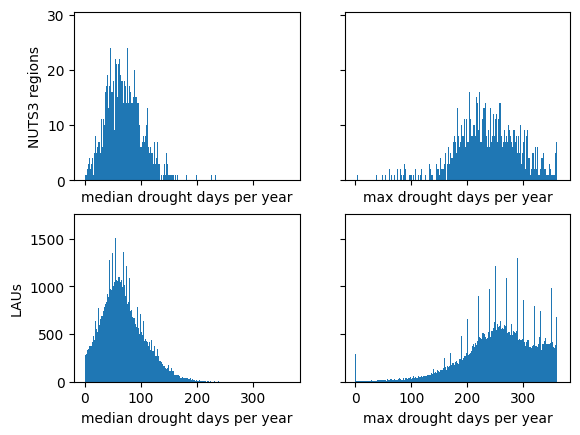

In [5]:
fig, axs = plt.subplots(2, 2, sharex=True, sharey="row")

for i, metric in enumerate(["median", "max"]):
    axs[0][i].hist(nuts3_df[f"{metric}_drought_days"].values, bins=365, range=(0, 366) )
    axs[0][i].set_xlabel(f"{metric} drought days per year")

    axs[1][i].hist(lau_df[f"{metric}_drought_days"].values, bins=365, range=(0, 366) )
    axs[1][i].set_xlabel(f"{metric} drought days per year")
    
axs[0][0].set_ylabel("NUTS3 regions")
axs[1][0].set_ylabel("LAUs")
plt.show()

In [6]:

avg_drought_days_gt_100 = len(lau_df[lau_df["median_drought_days"] > 100])
print(f"{avg_drought_days_gt_100} of {len(lau_df)} LAUs ({100* avg_drought_days_gt_100 / len(lau_df):.2f}%) experience more than 100 drought days per year.")

19134 of 98264 LAUs (19.47%) experience more than 100 drought days per year.


In [7]:
max_drought_days_gt_200 = len(lau_df[lau_df["max_drought_days"] > 200])
print(f"{max_drought_days_gt_200} of {len(lau_df)} LAUs ({100* max_drought_days_gt_200 / len(lau_df):.2f}%) experienced at least one year between 2012 and 2025 with over 200 drought days.")

print("most frequent 'worst year' at LAU-scale:")
print(lau_df["max_drought_days_year"].value_counts()[:5])

82305 of 98264 LAUs (83.76%) experienced at least one year between 2012 and 2025 with over 200 drought days.
most frequent 'worst year' at LAU-scale:
max_drought_days_year
2019    20158
2022    19620
2017    13364
2012    12989
2018     6999
Name: count, dtype: int64


In [8]:
nuts3_df["cropland_km2_by_type"] = nuts3_df["cropland_km2_by_type"].apply(lambda x: eval(x) if isinstance(x, str) else {})
high_drought_df = nuts3_df[nuts3_df["median_drought_days"] > 100]
low_drought_df = nuts3_df[nuts3_df["median_drought_days"] <= 100]

In [9]:
low_drought_crops = sum([Counter(dct) for dct in low_drought_df["cropland_km2_by_type"].values], Counter())
high_drought_crops= sum([Counter(dct) for dct in high_drought_df["cropland_km2_by_type"].values], Counter())

In [10]:
sum(low_drought_crops.values()) + sum(high_drought_crops.values())

1112703.3099999998

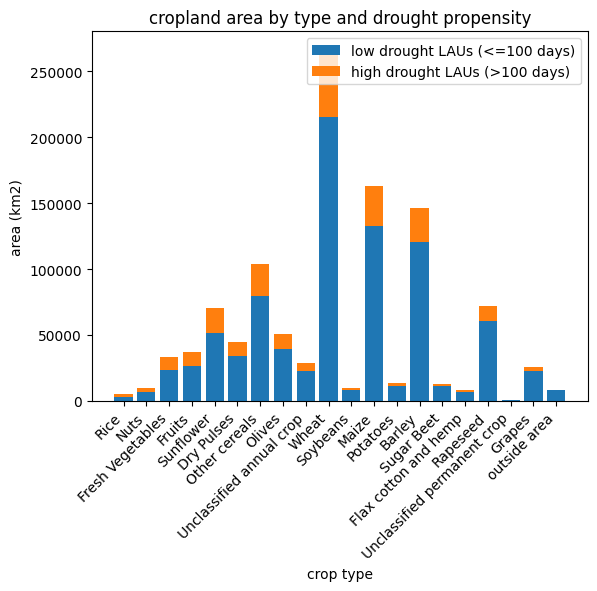

In [11]:
# 1. Align keys (intersection is safest)
keys = sorted(set(low_drought_crops) & set(high_drought_crops))

# 2. Compute ratio (avoid division by zero)
def safe_ratio(k):
    return low_drought_crops[k] / high_drought_crops[k] if high_drought_crops[k] != 0 else float('inf')

# 3. Sort keys by ratio
keys_sorted = sorted(keys, key=safe_ratio)

# 4. Extract values in sorted order
vals1 = np.array([low_drought_crops[k] for k in keys_sorted])
vals2 = np.array([high_drought_crops[k] for k in keys_sorted])

# 5. Plot stacked bar chart
x = np.arange(len(keys_sorted))

plt.figure()
plt.bar(x, vals1, label='low drought LAUs (<=100 days)')
plt.bar(x, vals2, bottom=vals1, label='high drought LAUs (>100 days)')

plt.xticks(x, keys_sorted, rotation=45, ha="right")
plt.legend()
plt.xlabel('crop type')
plt.ylabel('area (km2)')
plt.title('cropland area by type and drought propensity')

plt.show()

In [12]:
nuts3_df.dropna(subset="median_drought_days").sort_values(by="median_drought_days", ascending=False)

,nuts_id,cntr_code,nuts_name,population,area_km2,cropland_km2,cropland_area_percent,cropland_km2_by_type,name_latn,median_drought_days,max_drought_days,max_drought_days_year,median_warning_days,max_warning_days,max_warning_days_year,median_alert_days,max_alert_days,max_alert_days_year,geometry
1316,TRA23,TR,Iğdır,206857,3480.70,277.46,7.97,"{'Barley': 19.89, 'Other cereals': 42.07, 'Dry...",Iğdır,233.88,308.15,2025.0,204.75,293.86,2025.0,12.55,70.45,2022.0,"POLYGON ((44.76834 39.71415, 44.79976 39.68534..."
1302,TR832,TR,Tokat,612674,10069.84,1843.77,18.31,"{'Wheat': 214.38, 'Barley': 270.85, 'Other cer...",Tokat,226.06,291.22,2020.0,201.44,272.90,2025.0,19.93,59.81,2021.0,"POLYGON ((35.47122 40.17658, 35.46684 40.1799,..."
8,AL032,AL,Fier,233215,1881.63,475.27,25.26,"{'Wheat': 94.73, 'Barley': 38.71, 'Maize': 66....",Fier,199.85,334.84,2017.0,179.04,322.82,2017.0,4.97,55.96,2012.0,"POLYGON ((19.6006 41.06751, 19.61202 41.06339,..."
1303,TR833,TR,Çorum,521335,12795.88,4076.73,31.86,"{'Wheat': 928.62, 'Barley': 994.69, 'Maize': 1...",Çorum,181.98,326.51,2021.0,136.33,282.55,2025.0,20.28,58.50,2014.0,"POLYGON ((35.47122 40.58488, 35.47999 40.58013..."
1117,PL923,PL,Płocki,301682,3351.28,1796.01,53.59,"{'Wheat': 426.01, 'Barley': 103.91, 'Maize': 4...",Płocki,178.72,345.02,2019.0,155.50,314.56,2019.0,9.90,48.39,2016.0,"POLYGON ((19.65918 52.95975, 19.671 52.95638, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1406,UKH24,UK,Bedford,173237,476.51,NaN,NaN,{},Bedford,4.30,195.34,2025.0,2.14,179.02,2019.0,1.08,42.03,2025.0,"POLYGON ((-0.46532 52.32296, -0.44539 52.3149,..."
1436,UKJ12,UK,Milton Keynes,271677,309.10,NaN,NaN,{},Milton Keynes,3.72,178.93,2025.0,1.97,156.30,2012.0,0.54,42.01,2025.0,"POLYGON ((-0.63415 52.16806, -0.63003 52.16063..."
686,ES708,ES,Lanzarote,166878,846.56,13.49,1.59,"{'Fresh Vegetables': 0.77, 'Sunflower': 0.12, ...",Lanzarote,1.77,27.01,2024.0,1.22,1.55,2012.0,0.98,25.68,2024.0,"MULTIPOLYGON (((-13.46423 29.12811, -13.46333 ..."
690,FI195,FI,Pohjanmaa,180729,7822.57,971.40,12.42,"{'Barley': 454.79, 'Other cereals': 277.72, 'D...",Pohjanmaa,0.98,69.43,2019.0,0.12,60.54,2019.0,0.69,8.89,2019.0,"MULTIPOLYGON (((22.80338 63.85756, 22.81558 63..."


(array([58., 23., 20., 23., 21., 15., 20., 16., 22., 16., 11., 15., 14.,
        12., 16., 22., 17., 16., 11., 21.,  8., 16., 19., 16., 11., 18.,
         8., 15., 15.,  6., 14., 13., 14., 11., 20., 10., 17., 10.,  9.,
        14., 20., 13.,  8., 17., 17.,  6., 14., 12., 11., 14., 14., 11.,
        11., 11.,  6., 11.,  9., 11., 12., 10.,  7., 12., 11., 12., 10.,
        10., 13.,  3., 13.,  8.,  7.,  6.,  5., 11.,  8., 11.,  6., 12.,
         6.,  5., 10., 13., 13.,  7.,  8.,  6.,  4.,  9.,  5., 10.,  7.,
         8.,  5.,  5.,  2.,  7.,  7.,  6.,  5.,  8.,  9.,  4.,  3.,  2.,
         5.,  2.,  5.,  5.,  0.,  4.,  6.,  3.,  3.,  3.,  4.,  5.,  2.,
         3.,  1.,  3.,  2.,  1.,  2.,  4.,  1.,  0.,  2.,  1.,  0.,  1.,
         1.,  5.,  2.,  1.,  0.,  0.,  0.,  2.,  1.,  2.,  1.,  2.,  1.,
         3.,  2.,  0.,  2.,  1.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,
         0.,  1.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.

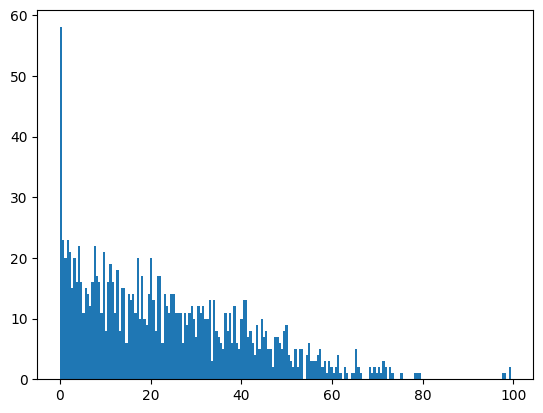

In [18]:
plt.hist(nuts3_df["cropland_area_percent"].values, bins=200)